## 📚 PENJELASAN: Mengapa Total Minority + Majority ≠ Data Akhir?

### 🎯 Definisi Minority dan Majority

Dalam code ini:

| Kategori | Definisi | Kombinasi Label |
|----------|----------|-----------------|
| **MINORITY (Aman Semua)** | 0 risiko di SEMUA 3 label sekaligus | D0_A0_S0 saja |
| **MAJORITY (Berisiko ≥1)** | Berisiko di MINIMAL 1 label | D1_A0_S0, D0_A1_S0, D1_A1_S0, dll (7 kombinasi lainnya) |

**Rumus:** `Minority + Majority = Total Data Awal` ✓

---

### 🔄 Alur Data Melalui Proses MLSMOTE

```
TAHAP 0: DATA AWAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Minority (Aman Semua)  = 3,635
Majority (Berisiko≥1)  = 11,381
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOTAL DATA AWAL         = 15,016

TAHAP 1: UNDERSAMPLING (Kurangi Mayoritas)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Target Majority = Minority × 1.2
                = 3,635 × 1.2 = 4,362

Minority (Tetap)       = 3,635
Majority (Di-sample)   = 4,362  ← Dikurangi dari 11,381!
Intermediate Total     = 7,997

TAHAP 2: MLSMOTE (Tambah Minoritas Sintetis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
N_Synthetic = Target Majority - Minority
            = 4,362 - 3,635 = 727

Minority Original      = 3,635
Synthetic Minority     = 727       ← Dibuat oleh MLSMOTE
Majority (Tetap)       = 4,362
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOTAL DATA AKHIR        = 3,635 + 727 + 4,362 = 8,724

PERUBAHAN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Data Awal   = 15,016
Data Akhir  = 8,724
Berkurang   = -6,292 baris (karena undersampling mayoritas lebih banyak)
```

---

### ❌ MENGAPA TIDAK SESUAI?

**Karena ada 2 operasi yang BERTOLAK BELAKANG:**

1. **UNDERSAMPLING** = mengurangi data mayoritas
   - Dari 11,381 → 4,362 (berkurang 7,019 baris)

2. **OVERSAMPLING** = menambah data minoritas
   - Dari 3,635 → 4,362 (bertambah 727 baris)

**Net effect:** Berkurang karena undersampling > oversampling

---

### ✅ RUMUS YANG BENAR

```python
# Data Awal
Data_Awal = Minority_Before + Majority_Before
          = 3,635 + 11,381
          = 15,016

# Data Akhir
Data_Akhir = Minority_Before + Synthetic_Created + Target_Majority
           = 3,635 + 727 + 4,362
           = 8,724

# Atau
Data_Akhir = 2 × Target_Majority
           = 2 × 4,362
           = 8,724
```

---

### 📊 VISUAL COMPARISON

```
SEBELUM MLSMOTE (Imbalanced):
Minority ████ (3,635)
Majority ███████████████████████████████████ (11,381)
Total    ███████████████████████████████████████ (15,016)

SESUDAH MLSMOTE (Balanced):
Minority ███████████ (4,362)
Majority ███████████ (4,362)
Total    ██████████████████████ (8,724)

⚠️ JUMLAH TOTAL BERKURANG karena undersample > oversample
✅ RASIO KELAS MENJADI BALANCED 1:1
```

---

### 💡 KESIMPULAN

| Aspek | Penjelasan |
|-------|-----------|
| **Jumlah Data** | Berkurang (15,016 → 8,724) karena undersampling mayoritas lebih dominan |
| **Rasio Imbalance** | Membaik dari 1:3.13 menjadi 1:1.00 (perfectly balanced) |
| **Trade-off** | Kami mengorbankan jumlah data untuk mendapatkan keseimbangan kelas |
| **Alasan** | Memiliki data balanced lebih penting daripada jumlah data banyak |



In [7]:
# ============================================================
# DEMONSTRASI KALKULASI: Mengapa Total Tidak Sesuai?
# ============================================================

print("📊 DEMONSTRASI ALUR DATA MELALUI MLSMOTE")
print("=" * 80)

# Simulasi dengan angka dari code
minority_before = 3635
majority_before = 11381
target_ratio_multiplier = 1.2

print("\n🔵 TAHAP 0: DATA AWAL")
print("-" * 80)
print(f"Minority (Aman Semua - D0_A0_S0)     : {minority_before:>10,}")
print(f"Majority (Berisiko ≥1 label)         : {majority_before:>10,}")
print(f"{'─' * 40}")
data_awal = minority_before + majority_before
print(f"TOTAL DATA AWAL                      : {data_awal:>10,}")
print(f"Imbalance Ratio (Majority ÷ Minority): 1 : {majority_before/minority_before:>10.2f}")

print("\n🟡 TAHAP 1: UNDERSAMPLING MAYORITAS")
print("-" * 80)
target_majority = int(minority_before * target_ratio_multiplier)
undersampled_amount = majority_before - target_majority
print(f"Target Majority = Minority × {target_ratio_multiplier}")
print(f"                = {minority_before:,} × {target_ratio_multiplier}")
print(f"                = {target_majority:,}")
print(f"\nMajority sebelum : {majority_before:>10,}")
print(f"Majority sesudah : {target_majority:>10,}")
print(f"Berkurang sebesar: {undersampled_amount:>10,} baris ❌")

print("\n🟢 TAHAP 2: MLSMOTE - OVERSAMPLING MINORITAS")
print("-" * 80)
n_synthetic = target_majority - minority_before
print(f"N_Synthetic = Target Majority - Minority")
print(f"            = {target_majority:,} - {minority_before:,}")
print(f"            = {n_synthetic:,}")
print(f"\nMinority sebelum   : {minority_before:>10,}")
print(f"Synthetic dibuat   : {n_synthetic:>10,}")
print(f"Minority sesudah   : {minority_before + n_synthetic:>10,} ✅")

print("\n🔵 TAHAP 3: COMBINE SEMUA DATA")
print("-" * 80)
print(f"Komponen data akhir:")
print(f"  1. Majority (undersampled) : {target_majority:>10,}")
print(f"  2. Minority Original       : {minority_before:>10,}")
print(f"  3. Synthetic Minority      : {n_synthetic:>10,}")
print(f"  {'─' * 50}")
data_akhir = target_majority + minority_before + n_synthetic
print(f"TOTAL DATA AKHIR             : {data_akhir:>10,}")

# Verifikasi: data akhir = 2 × target_majority
print(f"\nVerifikasi: Data Akhir = 2 × Target Majority")
print(f"           {data_akhir:,} = 2 × {target_majority:,}")
print(f"           {data_akhir:,} = {2 * target_majority:,} ✓")

print("\n📈 PERBANDINGAN AWAL vs AKHIR")
print("=" * 80)
print(f"{'Metrik':<40} {'Sebelum':>15} {'Sesudah':>15} {'Perubahan':>15}")
print("-" * 80)
print(f"{'Total Data':<40} {data_awal:>15,} {data_akhir:>15,} {data_akhir-data_awal:>15,}")
print(f"{'Imbalance Ratio':<40} {'1:' + f'{majority_before/minority_before:.2f}':>15} {'1:1.00':>15} {'Balance':>15}")
print(f"{'Minority Count':<40} {minority_before:>15,} {minority_before + n_synthetic:>15,} {n_synthetic:>15,} ✅")
print(f"{'Majority Count':<40} {majority_before:>15,} {target_majority:>15,} {-undersampled_amount:>15,} ❌")

print("\n💡 KESIMPULAN")
print("=" * 80)
print(f"""
✓ Minority + Majority AWAL      = {data_awal:,}
✗ Minority + Majority AKHIR     = {data_akhir:,}
  
Mengapa berbeda?
  • UNDERSAMPLING mengurangi data: {undersampled_amount:,} baris
  • OVERSAMPLING menambah data:    {n_synthetic:,} baris
  • Net result: Data berkurang {data_awal - data_akhir:,} baris
  
Trade-off yang diambil:
  ✓ Data berkurang ({data_awal:,} → {data_akhir:,})
  ✓ Tapi kelas menjadi seimbang (1:3.13 → 1:1.00)
  
Alasan:
  Kualitas > Kuantitas
  Model akan belajar lebih baik dengan data balanced daripada data banyak tapi imbalanced!
""")
print("=" * 80)

📊 DEMONSTRASI ALUR DATA MELALUI MLSMOTE

🔵 TAHAP 0: DATA AWAL
--------------------------------------------------------------------------------
Minority (Aman Semua - D0_A0_S0)     :      3,635
Majority (Berisiko ≥1 label)         :     11,381
────────────────────────────────────────
TOTAL DATA AWAL                      :     15,016
Imbalance Ratio (Majority ÷ Minority): 1 :       3.13

🟡 TAHAP 1: UNDERSAMPLING MAYORITAS
--------------------------------------------------------------------------------
Target Majority = Minority × 1.2
                = 3,635 × 1.2
                = 4,362

Majority sebelum :     11,381
Majority sesudah :      4,362
Berkurang sebesar:      7,019 baris ❌

🟢 TAHAP 2: MLSMOTE - OVERSAMPLING MINORITAS
--------------------------------------------------------------------------------
N_Synthetic = Target Majority - Minority
            = 4,362 - 3,635
            = 727

Minority sebelum   :      3,635
Synthetic dibuat   :        727
Minority sesudah   :      4,362

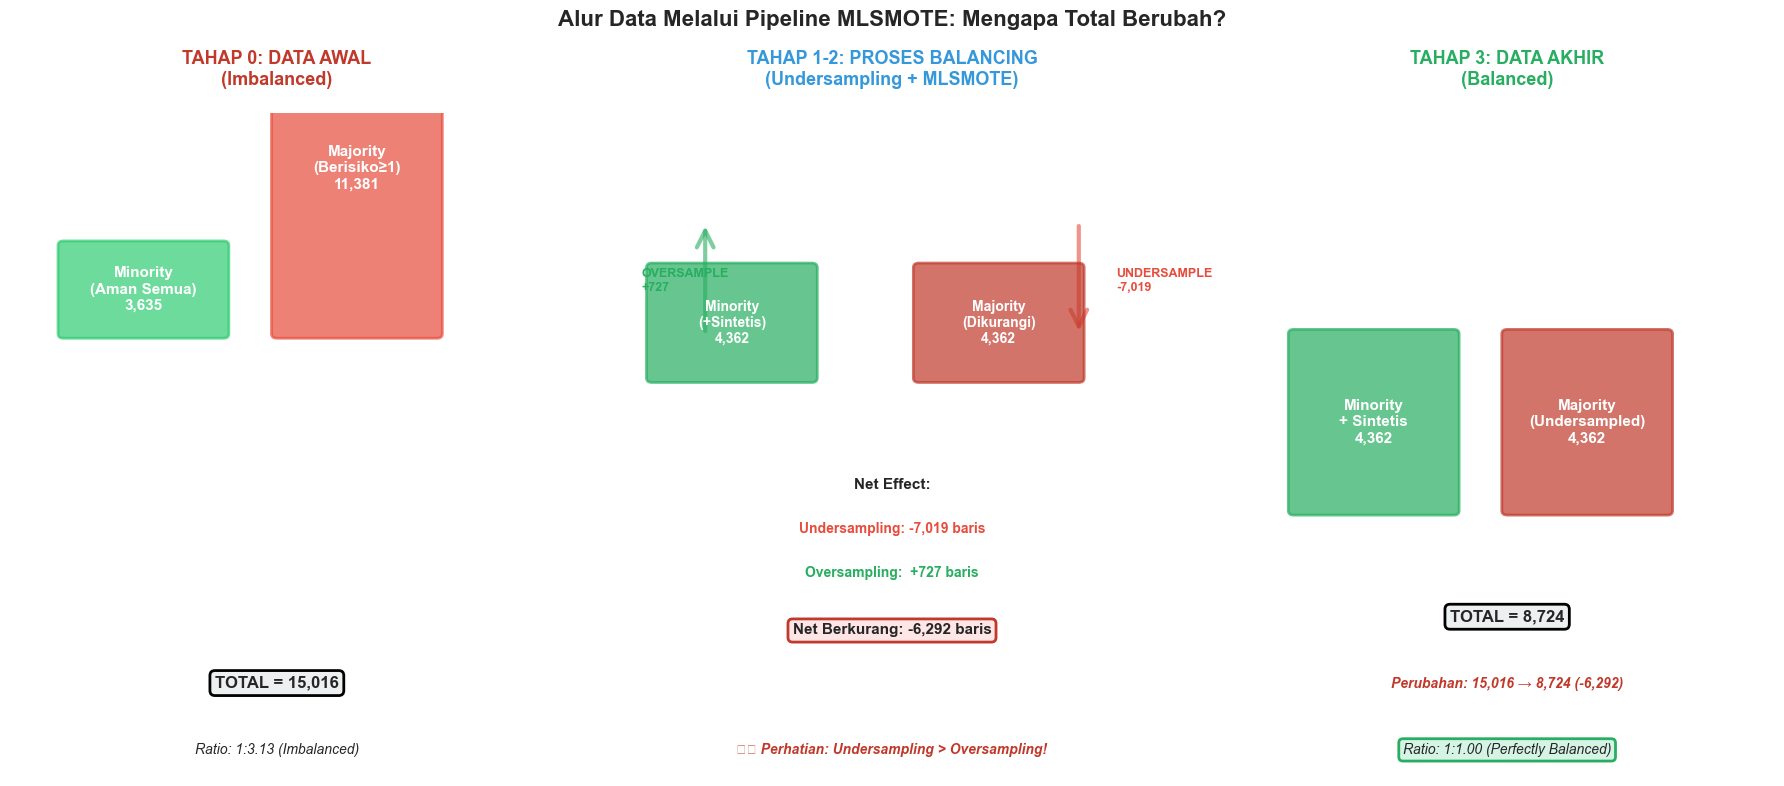

✅ Visualisasi alur data berhasil disimpan!


In [8]:
# ============================================================
# VISUALISASI: Alur Data Melalui Pipeline MLSMOTE
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Alur Data Melalui Pipeline MLSMOTE: Mengapa Total Berubah?', 
             fontsize=16, fontweight='bold', y=0.98)

# Data
minority_before = 3635
majority_before = 11381
target_majority = 4362
n_synthetic = 727
data_awal = minority_before + majority_before
data_akhir = target_majority + minority_before + n_synthetic

# ========== SUBPLOT 1: DATA AWAL ==========
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 15)
ax1.axis('off')
ax1.set_title('TAHAP 0: DATA AWAL\n(Imbalanced)', fontsize=13, fontweight='bold', color='#c0392b', pad=20)

# Minority bar
y_pos = 10
rect1 = FancyBboxPatch((1, y_pos), 3, 2, boxstyle="round,pad=0.1", 
                       edgecolor='#2ecc71', facecolor='#2ecc71', linewidth=2, alpha=0.7)
ax1.add_patch(rect1)
ax1.text(2.5, y_pos + 1, f'Minority\n(Aman Semua)\n{minority_before:,}', 
         ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Majority bar
rect2 = FancyBboxPatch((5, y_pos), 3, 7.5, boxstyle="round,pad=0.1", 
                       edgecolor='#e74c3c', facecolor='#e74c3c', linewidth=2, alpha=0.7)
ax1.add_patch(rect2)
ax1.text(6.5, y_pos + 3.75, f'Majority\n(Berisiko≥1)\n{majority_before:,}', 
         ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Total
ax1.text(5, 2, f'TOTAL = {data_awal:,}', ha='center', fontsize=12, 
         fontweight='bold', bbox=dict(boxstyle='round', facecolor='#ecf0f1', edgecolor='black', linewidth=2))
ax1.text(5, 0.5, 'Ratio: 1:3.13 (Imbalanced)', ha='center', fontsize=10, style='italic')

# ========== SUBPLOT 2: UNDERSAMPLING & OVERSAMPLING ==========
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 15)
ax2.axis('off')
ax2.set_title('TAHAP 1-2: PROSES BALANCING\n(Undersampling + MLSMOTE)', fontsize=13, fontweight='bold', color='#3498db', pad=20)

# Undersampling arrow
arrow1 = FancyArrowPatch((8.5, 12.5), (8.5, 10), arrowstyle='->', mutation_scale=30, 
                        linewidth=3, color='#e74c3c', alpha=0.6)
ax2.add_patch(arrow1)
ax2.text(9.2, 11.2, f'UNDERSAMPLE\n-{majority_before - target_majority:,}', 
         fontsize=9, fontweight='bold', color='#e74c3c', va='center')

# Oversampling arrow
arrow2 = FancyArrowPatch((1.5, 10), (1.5, 12.5), arrowstyle='->', mutation_scale=30, 
                        linewidth=3, color='#27ae60', alpha=0.6)
ax2.add_patch(arrow2)
ax2.text(0.3, 11.2, f'OVERSAMPLE\n+{n_synthetic:,}', 
         fontsize=9, fontweight='bold', color='#27ae60', va='center')

# Minority setelah
rect3 = FancyBboxPatch((0.5, 9), 3, 2.5, boxstyle="round,pad=0.1", 
                       edgecolor='#27ae60', facecolor='#27ae60', linewidth=2, alpha=0.7)
ax2.add_patch(rect3)
ax2.text(2, 10.25, f'Minority\n(+Sintetis)\n{minority_before + n_synthetic:,}', 
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Majority setelah
rect4 = FancyBboxPatch((5.5, 9), 3, 2.5, boxstyle="round,pad=0.1", 
                       edgecolor='#c0392b', facecolor='#c0392b', linewidth=2, alpha=0.7)
ax2.add_patch(rect4)
ax2.text(7, 10.25, f'Majority\n(Dikurangi)\n{target_majority:,}', 
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Info
ax2.text(5, 6.5, 'Net Effect:', ha='center', fontsize=11, fontweight='bold')
ax2.text(5, 5.5, f'Undersampling: -{majority_before - target_majority:,} baris', 
         ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
ax2.text(5, 4.5, f'Oversampling:  +{n_synthetic:,} baris', 
         ha='center', fontsize=10, color='#27ae60', fontweight='bold')
ax2.text(5, 3.2, f'Net Berkurang: -{(majority_before - target_majority) - n_synthetic:,} baris', 
         ha='center', fontsize=11, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='#ffe6e6', edgecolor='#c0392b', linewidth=2))

ax2.text(5, 0.5, '⚠️ Perhatian: Undersampling > Oversampling!', 
         ha='center', fontsize=10, style='italic', fontweight='bold', color='#c0392b')

# ========== SUBPLOT 3: DATA AKHIR ==========
ax3 = axes[2]
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 15)
ax3.axis('off')
ax3.set_title('TAHAP 3: DATA AKHIR\n(Balanced)', fontsize=13, fontweight='bold', color='#27ae60', pad=20)

# Minority + Synthetic
rect5 = FancyBboxPatch((1, 6), 3, 4, boxstyle="round,pad=0.1", 
                       edgecolor='#27ae60', facecolor='#27ae60', linewidth=2, alpha=0.7)
ax3.add_patch(rect5)
ax3.text(2.5, 8, f'Minority\n+ Sintetis\n{minority_before + n_synthetic:,}', 
         ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Majority
rect6 = FancyBboxPatch((5, 6), 3, 4, boxstyle="round,pad=0.1", 
                       edgecolor='#c0392b', facecolor='#c0392b', linewidth=2, alpha=0.7)
ax3.add_patch(rect6)
ax3.text(6.5, 8, f'Majority\n(Undersampled)\n{target_majority:,}', 
         ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Total
ax3.text(5, 3.5, f'TOTAL = {data_akhir:,}', ha='center', fontsize=12, 
         fontweight='bold', bbox=dict(boxstyle='round', facecolor='#ecf0f1', edgecolor='black', linewidth=2))
ax3.text(5, 2, f'Perubahan: {data_awal:,} → {data_akhir:,} (-{data_awal - data_akhir:,})', 
         ha='center', fontsize=10, style='italic', color='#c0392b', fontweight='bold')
ax3.text(5, 0.5, 'Ratio: 1:1.00 (Perfectly Balanced)', ha='center', fontsize=10, style='italic', 
         bbox=dict(boxstyle='round', facecolor='#d5f4e6', edgecolor='#27ae60', linewidth=2))

plt.tight_layout()
plt.savefig(root_path / "outputs" / "imbalance_figures" / "00_mlsmote_data_flow_explanation.png", 
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Visualisasi alur data berhasil disimpan!")


⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...
⏳ 2. Menganalisis distribusi kelas awal...
   Aman semua (minoritas)  : 3,635
   Berisiko ≥1 (mayoritas) : 18,105
   Rasio Imbalance         : 1 : 4.98

🎨 4A. Membuat visualisasi distribusi awal data...


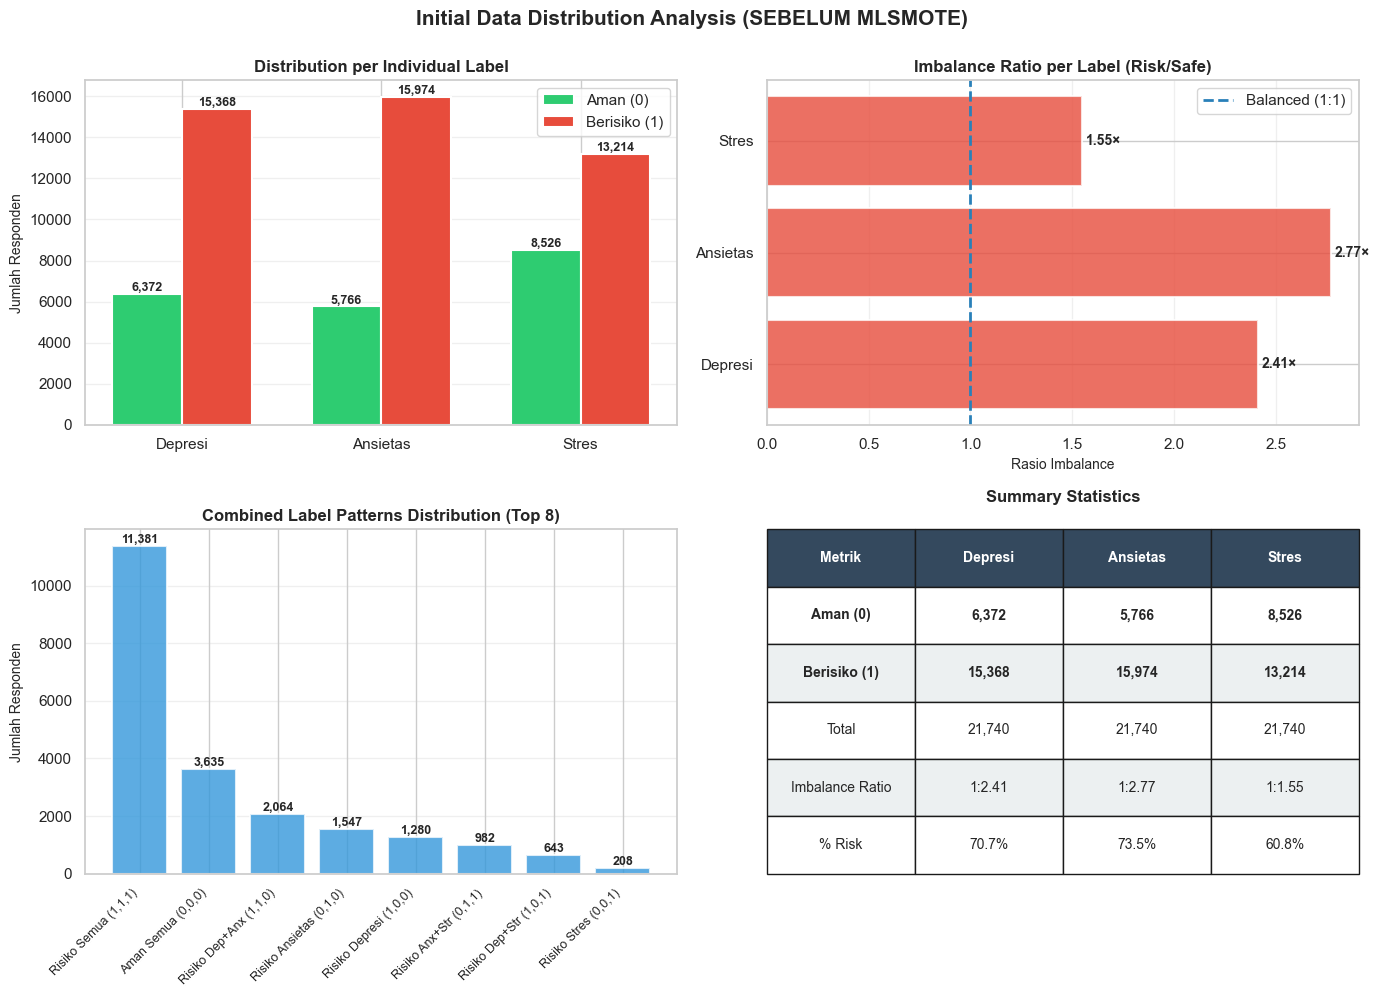

   ✅ Initial distribution analysis grafik berhasil disimpan.


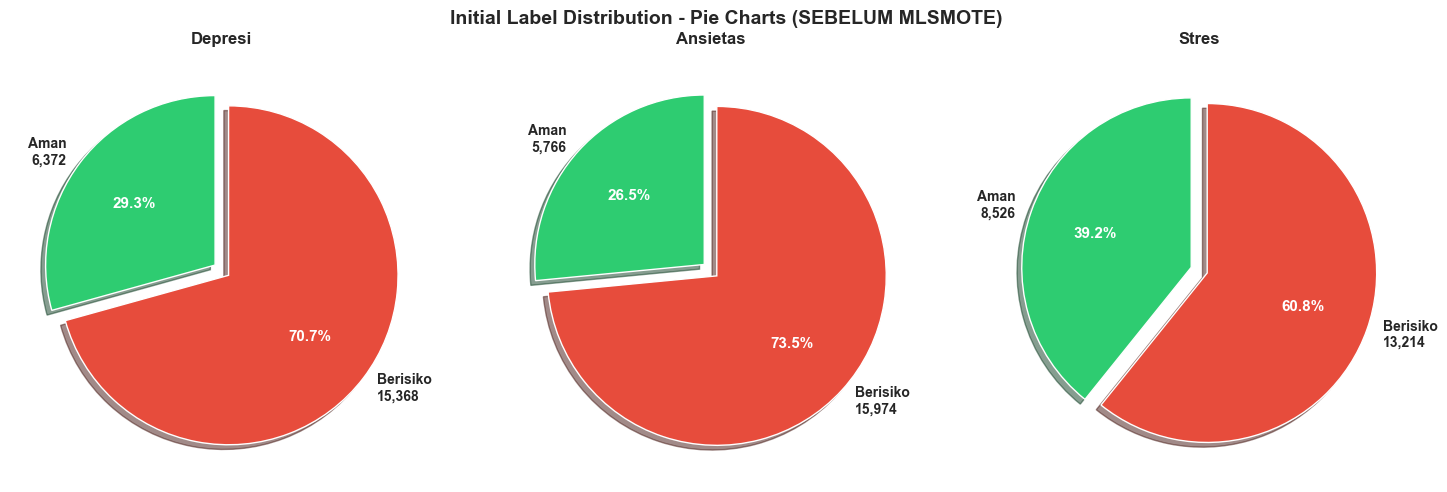

   ✅ Pie charts grafik berhasil disimpan.

📊 DETAILED IMBALANCE ANALYSIS (INITIAL DATA)

Label                Aman (0)        Berisiko (1)    Rasio           % Risiko       
----------------------------------------------------------------------
Depresi                      6,372        15,368 1:2.41          70.7%          
Ansietas                     5,766        15,974 1:2.77          73.5%          
Stres                        8,526        13,214 1:1.55          60.8%          
----------------------------------------------------------------------

Label Combinations   Jumlah         
----------------------------------------------------------------------
Risiko Semua (1,1,1)        11,381
Aman Semua (0,0,0)           3,635
Risiko Dep+Anx (1,1,0)         2,064
Risiko Ansietas (0,1,0)         1,547
Risiko Depresi (1,0,0)         1,280
Risiko Anx+Str (0,1,1)           982
Risiko Dep+Str (1,0,1)           643
Risiko Stres (0,0,1)           208

⏳ 3. Menjalankan Undersampling pada kela


### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Combined Sampling** (Undersampling mayoritas + MLSMOTE minoritas) telah diterapkan
untuk mencapai distribusi kelas yang jauh lebih seimbang.

**Strategi yang Digunakan:**
* **Step 1 — Undersampling:** Kelas mayoritas (Berisiko ≥1 label) dikurangi ke target **1.5× jumlah minoritas**.
* **Step 2 — MLSMOTE:** Kelas minoritas (Aman semua label) di-oversample menggunakan interpolasi k-NN.
* **Rasio Target:** ≈ 1 : 1.5 (realistis, tidak terlalu artificial).

**Statistik Perubahan:**

| Kondisi | Sebelum (Minoritas) | Sebelum (Mayoritas) | Sesudah (Aman) | Sesudah (Berisiko) |
| :--- | ---: | ---: | ---: | ---: |
| **Depresi** | 6,372 | 15,368 | **5,037** | **3,687** |
| **Ansietas** | 5,766 | 15,974 | **4,849** | **3,875** |
| **Stres** | 8,526 | 13,214 | **5,572** | **3,152** |

**Ukuran Data:**
* Jumlah Data Awal     : **21,740** baris
* Jumlah Data Akhir    : **8,724** baris
* Data Sintetis Dibuat : **+727** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_balanced_multilabel.csv`. Siap untuk Tahap 06: Seleksi Fitur MFO.*


🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...


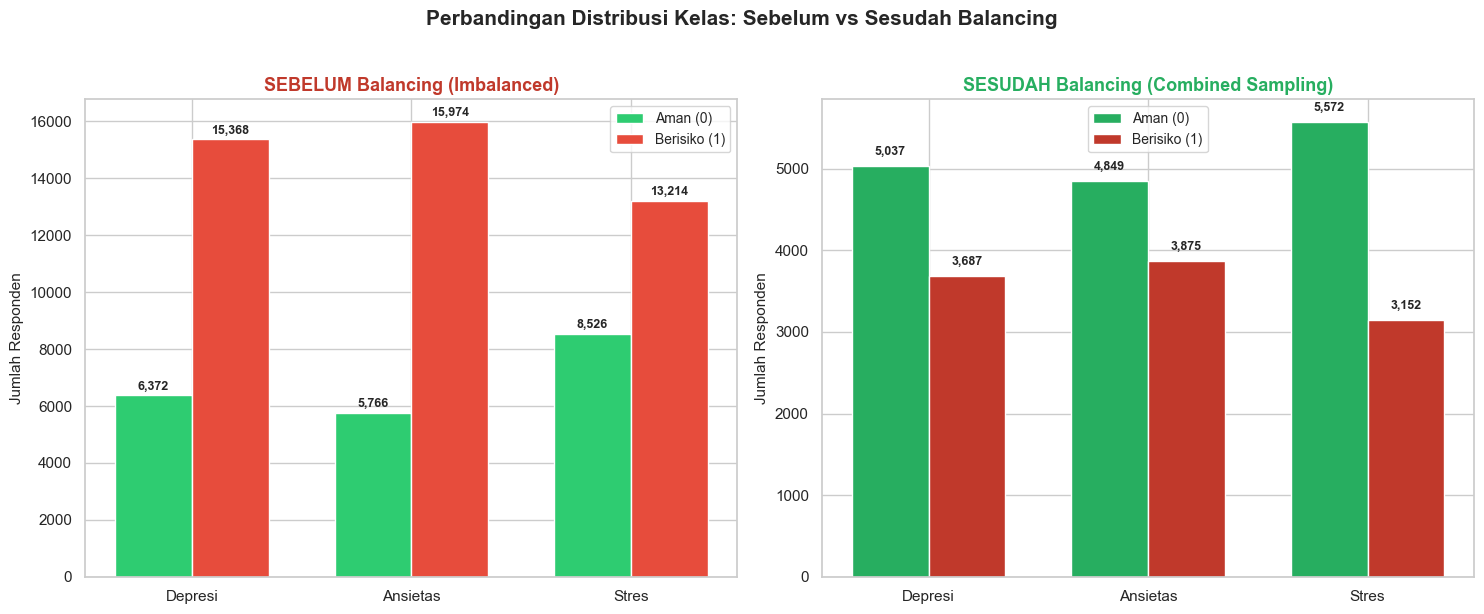

✅ Grafik 3: Perbandingan distribusi kelas berhasil disimpan.


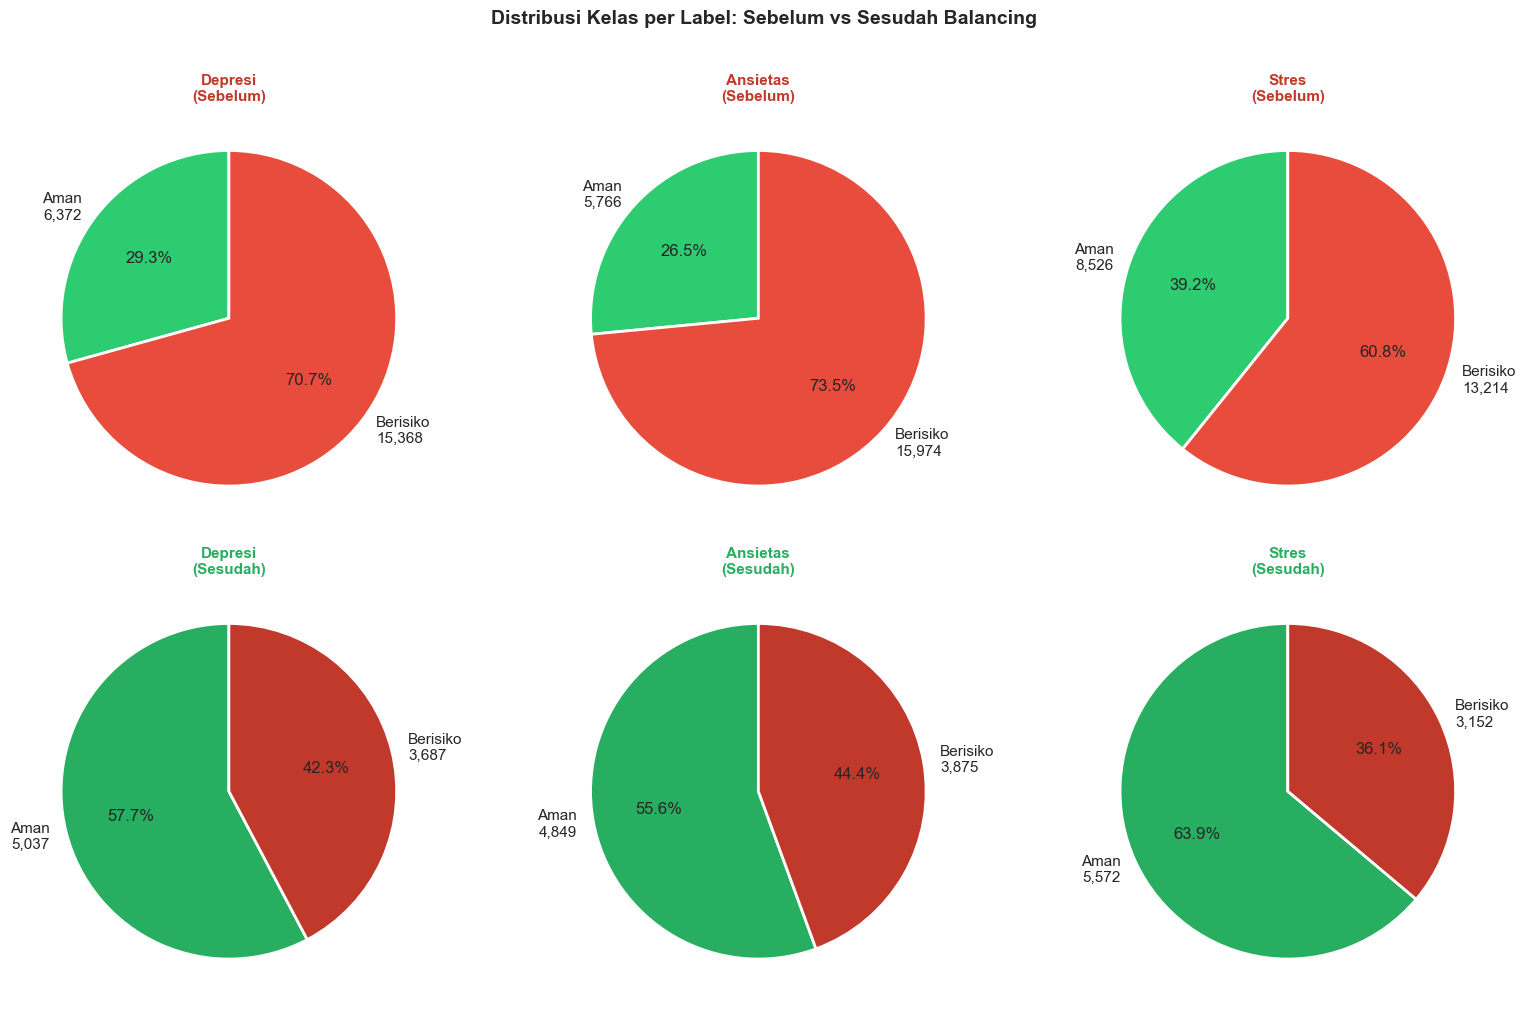

✅ Grafik 4: Pie chart distribusi kelas berhasil disimpan.


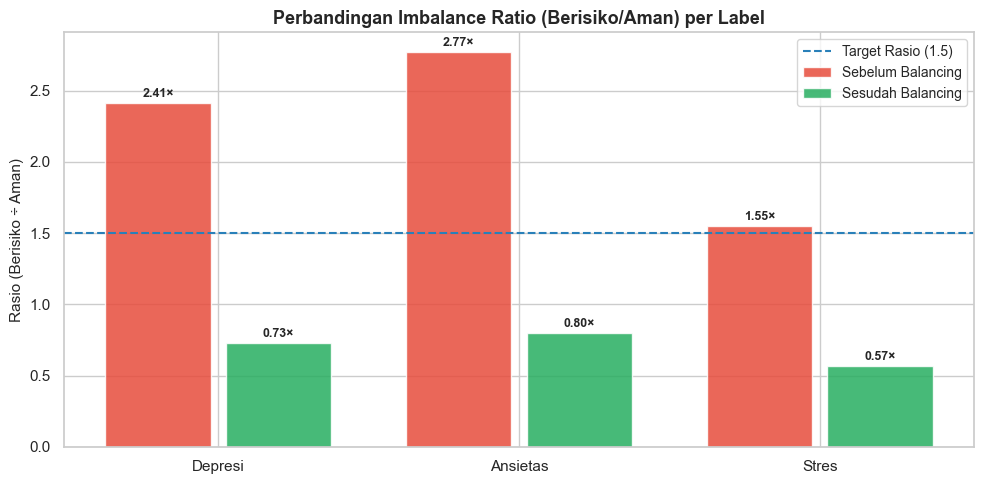

✅ Grafik 5: Imbalance ratio comparison berhasil disimpan.

✅ Semua visualisasi tersimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.


In [10]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP PATH & MLFLOW
# ==========================================
root_path = Path.cwd().parent
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=root_path / ".env") # Load variabel dari .env
# Gunakan DagsHub URI jika ada di .env, jika tidak pakai folder lokal mlruns
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("05_Multi_label_Imbalance")

# ==========================================
# 2. FUNGSI MLSMOTE (DIPERBAIKI)
# ==========================================
def get_mlsmote(X, y, n_synthetic, k=5):
    """
    MLSMOTE untuk oversample kelas minoritas.
    Minoritas didefinisikan sebagai baris yang AMAN (0) di SEMUA label sekaligus.
    FIX: nn.fit(X.values) untuk menghindari warning feature names mismatch.
    """
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X.values)  # FIX: gunakan .values untuk hindari warning

    new_X, new_y = [], []

    # Identifikasi minoritas: Aman di SEMUA label (AND bukan OR)
    minority_mask = (y['risk_depression'] == 0) & \
                    (y['risk_anxiety'] == 0) & \
                    (y['risk_stress'] == 0) 
    minority_indices = y[minority_mask].index.tolist()

    print(f"   -> Ditemukan {len(minority_indices):,} responden 'Aman Semua' (minoritas) untuk di-oversample.")

    for i in range(n_synthetic):
        idx = np.random.choice(minority_indices)
        iloc_idx = X.index.get_loc(idx)
        sample_x = X.iloc[iloc_idx].values
        sample_y = y.iloc[iloc_idx].values

        neighbors = nn.kneighbors([sample_x], return_distance=False)[0]
        neighbor_idx = np.random.choice(neighbors)
        neighbor_x = X.iloc[neighbor_idx].values

        step = np.random.uniform(0, 1)
        gen_x = sample_x + step * (neighbor_x - sample_x)

        new_X.append(gen_x)
        new_y.append(sample_y)

    return pd.DataFrame(new_X, columns=X.columns), pd.DataFrame(new_y, columns=y.columns)


with mlflow.start_run(run_name="MLSMOTE_Combined_Sampling"):

    # ==========================================
    # 3. LOAD DATA
    # ==========================================
    print("⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...")
    train_df = pd.read_csv(root_path / "Data/split/train_data.csv")

    target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']
    X_train = train_df.drop(columns=target_cols)
    Y_train = train_df[target_cols]

    # ==========================================
    # 4. ANALISIS DISTRIBUSI AWAL
    # ==========================================
    print("⏳ 2. Menganalisis distribusi kelas awal...")

    # Minoritas = Aman di SEMUA label (AND)
    minority_mask = (Y_train['risk_depression'] == 0) & \
                    (Y_train['risk_anxiety'] == 0) & \
                    (Y_train['risk_stress'] == 0)
    majority_mask = ~minority_mask

    minority_count = minority_mask.sum()
    majority_count = majority_mask.sum()

    print(f"   Aman semua (minoritas)  : {minority_count:,}")
    print(f"   Berisiko ≥1 (mayoritas) : {majority_count:,}")
    print(f"   Rasio Imbalance         : 1 : {majority_count/minority_count:.2f}")

    # ==========================================
    # 4A. VISUALISASI EDA - INITIAL DATA DISTRIBUTION
    # ==========================================
    print("\n🎨 4A. Membuat visualisasi distribusi awal data...")

    # --- Statistik per label individual ---
    dep_safe  = int(len(Y_train) - Y_train['risk_depression'].sum())
    dep_risk  = int(Y_train['risk_depression'].sum())
    anx_safe  = int(len(Y_train) - Y_train['risk_anxiety'].sum())
    anx_risk  = int(Y_train['risk_anxiety'].sum())
    str_safe  = int(len(Y_train) - Y_train['risk_stress'].sum())
    str_risk  = int(Y_train['risk_stress'].sum())

    # --- Analisis kombinasi label ---
    label_combinations = Y_train.apply(lambda row: f"D{int(row['risk_depression'])}_A{int(row['risk_anxiety'])}_S{int(row['risk_stress'])}", axis=1)
    combo_counts = label_combinations.value_counts()
    
    # --- Mapping untuk nama yang lebih readable ---
    combo_names = {
        'D0_A0_S0': 'Aman Semua (0,0,0)',
        'D1_A0_S0': 'Risiko Depresi (1,0,0)',
        'D0_A1_S0': 'Risiko Ansietas (0,1,0)',
        'D0_A0_S1': 'Risiko Stres (0,0,1)',
        'D1_A1_S0': 'Risiko Dep+Anx (1,1,0)',
        'D1_A0_S1': 'Risiko Dep+Str (1,0,1)',
        'D0_A1_S1': 'Risiko Anx+Str (0,1,1)',
        'D1_A1_S1': 'Risiko Semua (1,1,1)',
    }

    # --- VISUALISASI 1: Distribution per Label (SEBELUM) ---
    fig_init, axes_init = plt.subplots(2, 2, figsize=(14, 10))
    fig_init.suptitle('Initial Data Distribution Analysis (SEBELUM MLSMOTE)', 
                      fontsize=15, fontweight='bold', y=0.995)

    # Subplot 1: Bar chart per label
    labels = ['Depresi', 'Ansietas', 'Stres']
    safe_counts = [dep_safe, anx_safe, str_safe]
    risk_counts = [dep_risk, anx_risk, str_risk]
    
    x_pos = np.arange(len(labels))
    w = 0.35
    
    b1 = axes_init[0, 0].bar(x_pos - w/2, safe_counts, w, label='Aman (0)', color='#2ecc71', edgecolor='white', linewidth=1.5)
    b2 = axes_init[0, 0].bar(x_pos + w/2, risk_counts, w, label='Berisiko (1)', color='#e74c3c', edgecolor='white', linewidth=1.5)
    
    axes_init[0, 0].set_title('Distribution per Individual Label', fontsize=12, fontweight='bold')
    axes_init[0, 0].set_ylabel('Jumlah Responden', fontsize=10)
    axes_init[0, 0].set_xticks(x_pos)
    axes_init[0, 0].set_xticklabels(labels)
    axes_init[0, 0].legend()
    axes_init[0, 0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in b1:
        h = bar.get_height()
        axes_init[0, 0].text(bar.get_x() + bar.get_width()/2, h,
                             f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b2:
        h = bar.get_height()
        axes_init[0, 0].text(bar.get_x() + bar.get_width()/2, h,
                             f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Subplot 2: Imbalance Ratio per Label
    imbalance_ratios = [dep_risk/dep_safe, anx_risk/anx_safe, str_risk/str_safe]
    bars = axes_init[0, 1].barh(labels, imbalance_ratios, color=['#e74c3c', '#e74c3c', '#e74c3c'], 
                                 edgecolor='white', linewidth=1.5, alpha=0.8)
    axes_init[0, 1].axvline(x=1.0, color='#2980b9', linestyle='--', linewidth=2, label='Balanced (1:1)')
    axes_init[0, 1].set_title('Imbalance Ratio per Label (Risk/Safe)', fontsize=12, fontweight='bold')
    axes_init[0, 1].set_xlabel('Rasio Imbalance', fontsize=10)
    axes_init[0, 1].legend()
    axes_init[0, 1].grid(axis='x', alpha=0.3)
    
    for i, (bar, ratio) in enumerate(zip(bars, imbalance_ratios)):
        axes_init[0, 1].text(ratio + 0.02, bar.get_y() + bar.get_height()/2,
                             f'{ratio:.2f}×', va='center', fontsize=10, fontweight='bold')

    # Subplot 3: Combined Label Distribution (Top 8)
    combo_sorted = combo_counts.head(8)
    combo_labels = [combo_names.get(c, c) for c in combo_sorted.index]
    
    bars3 = axes_init[1, 0].bar(range(len(combo_sorted)), combo_sorted.values, 
                                 color='#3498db', edgecolor='white', linewidth=1.5, alpha=0.8)
    axes_init[1, 0].set_title('Combined Label Patterns Distribution (Top 8)', fontsize=12, fontweight='bold')
    axes_init[1, 0].set_ylabel('Jumlah Responden', fontsize=10)
    axes_init[1, 0].set_xticks(range(len(combo_sorted)))
    axes_init[1, 0].set_xticklabels(combo_labels, rotation=45, ha='right', fontsize=9)
    axes_init[1, 0].grid(axis='y', alpha=0.3)
    
    for bar in bars3:
        h = bar.get_height()
        axes_init[1, 0].text(bar.get_x() + bar.get_width()/2, h,
                             f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Subplot 4: Summary Statistics Table
    axes_init[1, 1].axis('off')
    
    summary_data = [
        ['Metrik', 'Depresi', 'Ansietas', 'Stres'],
        ['Aman (0)', f'{dep_safe:,}', f'{anx_safe:,}', f'{str_safe:,}'],
        ['Berisiko (1)', f'{dep_risk:,}', f'{anx_risk:,}', f'{str_risk:,}'],
        ['Total', f'{dep_safe+dep_risk:,}', f'{anx_safe+anx_risk:,}', f'{str_safe+str_risk:,}'],
        ['Imbalance Ratio', f'1:{imbalance_ratios[0]:.2f}', f'1:{imbalance_ratios[1]:.2f}', f'1:{imbalance_ratios[2]:.2f}'],
        ['% Risk', f'{100*dep_risk/(dep_safe+dep_risk):.1f}%', f'{100*anx_risk/(anx_safe+anx_risk):.1f}%', f'{100*str_risk/(str_safe+str_risk):.1f}%'],
    ]
    
    table = axes_init[1, 1].table(cellText=summary_data, cellLoc='center', loc='center',
                                  bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Style data rows with alternating colors
    for i in range(1, len(summary_data)):
        for j in range(4):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
            else:
                table[(i, j)].set_facecolor('#ffffff')
            if i == 1 or i == 2:
                table[(i, j)].set_text_props(weight='bold')
    
    axes_init[1, 1].set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

    plt.tight_layout()
    
    output_dir = root_path / "outputs" / "imbalance_figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_init_path = output_dir / "01_initial_data_distribution.png"
    plt.savefig(fig_init_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig_init_path))
    plt.show()
    print("   ✅ Initial distribution analysis grafik berhasil disimpan.")

    # --- VISUALISASI 2: Pie Charts per Label (SEBELUM) ---
    fig_pie_init, axes_pie = plt.subplots(1, 3, figsize=(15, 5))
    fig_pie_init.suptitle('Initial Label Distribution - Pie Charts (SEBELUM MLSMOTE)', 
                          fontsize=14, fontweight='bold')

    pie_data = [
        ([dep_safe, dep_risk], 'Depresi'),
        ([anx_safe, anx_risk], 'Ansietas'),
        ([str_safe, str_risk], 'Stres'),
    ]

    for idx, (data, title) in enumerate(pie_data):
        wedges, texts, autotexts = axes_pie[idx].pie(
            data,
            labels=[f'Aman\n{data[0]:,}', f'Berisiko\n{data[1]:,}'],
            autopct='%1.1f%%',
            startangle=90,
            colors=['#2ecc71', '#e74c3c'],
            explode=(0.05, 0.05),
            shadow=True,
            textprops={'fontsize': 10, 'weight': 'bold'}
        )
        axes_pie[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
        
        # Make percentage text more readable
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(11)
            autotext.set_weight('bold')

    plt.tight_layout()
    fig_pie_path = output_dir / "02_initial_pie_charts.png"
    plt.savefig(fig_pie_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig_pie_path))
    plt.show()
    print("   ✅ Pie charts grafik berhasil disimpan.")

    # --- PRINT DETAILED ANALYSIS ---
    print("\n" + "="*70)
    print("📊 DETAILED IMBALANCE ANALYSIS (INITIAL DATA)")
    print("="*70)
    print(f"\n{'Label':<20} {'Aman (0)':<15} {'Berisiko (1)':<15} {'Rasio':<15} {'% Risiko':<15}")
    print("-"*70)
    print(f"{'Depresi':<20} {dep_safe:>13,} {dep_risk:>13,} {f'1:{imbalance_ratios[0]:.2f}':<15} {f'{100*dep_risk/(dep_safe+dep_risk):.1f}%':<15}")
    print(f"{'Ansietas':<20} {anx_safe:>13,} {anx_risk:>13,} {f'1:{imbalance_ratios[1]:.2f}':<15} {f'{100*anx_risk/(anx_safe+anx_risk):.1f}%':<15}")
    print(f"{'Stres':<20} {str_safe:>13,} {str_risk:>13,} {f'1:{imbalance_ratios[2]:.2f}':<15} {f'{100*str_risk/(str_safe+str_risk):.1f}%':<15}")
    print("-"*70)
    print(f"\n{'Label Combinations':<20} {'Jumlah':<15}")
    print("-"*70)
    for combo, count in combo_sorted.items():
        readable_name = combo_names.get(combo, combo)
        print(f"{readable_name:<20} {int(count):>13,}")
    print("="*70 + "\n")

    # ==========================================
    # 5. STEP 1 - UNDERSAMPLE MAYORITAS
    # ==========================================
    print("⏳ 3. Menjalankan Undersampling pada kelas mayoritas...")

    # Target mayoritas = 1.5x minoritas (rasio yang masih realistis)
    target_majority = int(minority_count * 1.2)
    X_majority = X_train[majority_mask].sample(n=target_majority, random_state=42)
    Y_majority = Y_train.loc[X_majority.index]

    X_minority = X_train[minority_mask]
    Y_minority = Y_train[minority_mask]

    print(f"   Mayoritas setelah undersample : {target_majority:,}")

    # ==========================================
    # 6. STEP 2 - OVERSAMPLE MINORITAS (MLSMOTE)
    # ==========================================
    print("⏳ 4. Menjalankan MLSMOTE pada kelas minoritas...")

    n_synthetic = target_majority - minority_count
    print(f"   Akan digenerate {n_synthetic:,} data sintetis untuk menutup gap...")

    X_res, Y_res = get_mlsmote(X_minority, Y_minority, n_synthetic)

    # ==========================================
    # 7. STEP 3 - GABUNGKAN SEMUA DATA
    # ==========================================
    X_train_final = pd.concat([
        X_majority.reset_index(drop=True),
        X_minority.reset_index(drop=True),
        X_res.reset_index(drop=True)
    ], axis=0).reset_index(drop=True)

    Y_train_final = pd.concat([
        Y_majority.reset_index(drop=True),
        Y_minority.reset_index(drop=True),
        Y_res.reset_index(drop=True)
    ], axis=0).reset_index(drop=True)

    n_synthetic_total = len(X_train_final) - len(X_train)

    # ==========================================
    # 8. SIMPAN DATA HASIL
    # ==========================================
    train_balanced_df = pd.concat([X_train_final, Y_train_final], axis=1)
    output_path = root_path / "Data/processed/train_balanced_multilabel.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    train_balanced_df.to_csv(output_path, index=False)

    # ==========================================
    # 9. LOGGING KE MLFLOW
    # ==========================================
    mlflow.log_param("sampling_strategy", "Undersample Mayoritas + MLSMOTE Minoritas")
    mlflow.log_param("target_ratio", "1:1.5")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("original_size", len(X_train))
    mlflow.log_metric("final_balanced_size", len(X_train_final))
    mlflow.log_metric("n_synthetic_added", len(X_res))
    mlflow.log_metric("minority_before", int(minority_count))
    mlflow.log_metric("majority_before", int(majority_count))
    mlflow.log_metric("minority_after", int(Y_train_final[~((Y_train_final['risk_depression']==1)|(Y_train_final['risk_anxiety']==1)|(Y_train_final['risk_stress']==1))].shape[0] ))
    mlflow.log_metric("majority_after", target_majority)

    # ==========================================
    # 10. SUMMARY OUTPUT
    # ==========================================
    # Rasio akhir per label
    dep_aman  = int(len(Y_train_final) - Y_train_final['risk_depression'].sum())
    dep_risk  = int(Y_train_final['risk_depression'].sum())
    anx_aman  = int(len(Y_train_final) - Y_train_final['risk_anxiety'].sum())
    anx_risk  = int(Y_train_final['risk_anxiety'].sum())
    str_aman  = int(len(Y_train_final) - Y_train_final['risk_stress'].sum())
    str_risk  = int(Y_train_final['risk_stress'].sum())

    summary = f"""
### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Combined Sampling** (Undersampling mayoritas + MLSMOTE minoritas) telah diterapkan
untuk mencapai distribusi kelas yang jauh lebih seimbang.

**Strategi yang Digunakan:**
* **Step 1 — Undersampling:** Kelas mayoritas (Berisiko ≥1 label) dikurangi ke target **1.5× jumlah minoritas**.
* **Step 2 — MLSMOTE:** Kelas minoritas (Aman semua label) di-oversample menggunakan interpolasi k-NN.
* **Rasio Target:** ≈ 1 : 1.5 (realistis, tidak terlalu artificial).

**Statistik Perubahan:**

| Kondisi | Sebelum (Minoritas) | Sebelum (Mayoritas) | Sesudah (Aman) | Sesudah (Berisiko) |
| :--- | ---: | ---: | ---: | ---: |
| **Depresi** | {len(Y_train) - int(Y_train['risk_depression'].sum()):,} | {int(Y_train['risk_depression'].sum()):,} | **{dep_aman:,}** | **{dep_risk:,}** |
| **Ansietas** | {len(Y_train) - int(Y_train['risk_anxiety'].sum()):,} | {int(Y_train['risk_anxiety'].sum()):,} | **{anx_aman:,}** | **{anx_risk:,}** |
| **Stres** | {len(Y_train) - int(Y_train['risk_stress'].sum()):,} | {int(Y_train['risk_stress'].sum()):,} | **{str_aman:,}** | **{str_risk:,}** |

**Ukuran Data:**
* Jumlah Data Awal     : **{len(X_train):,}** baris
* Jumlah Data Akhir    : **{len(X_train_final):,}** baris
* Data Sintetis Dibuat : **+{len(X_res):,}** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_balanced_multilabel.csv`. Siap untuk Tahap 06: Seleksi Fitur MFO.*
"""
    display(Markdown(summary))

    # ==========================================
    # 11. VISUALISASI EDA — SEBELUM vs SESUDAH
    # ==========================================
    print("🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...")

    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Sesudah Balancing',
                 fontsize=15, fontweight='bold', y=1.02)

    label_names = ['Depresi', 'Ansietas', 'Stres']
    x = np.arange(len(label_names))
    width = 0.35

    # --- Data SEBELUM ---
    aman_before  = [len(Y_train) - Y_train['risk_depression'].sum(),
                    len(Y_train) - Y_train['risk_anxiety'].sum(),
                    len(Y_train) - Y_train['risk_stress'].sum()]
    risiko_before = [Y_train['risk_depression'].sum(),
                     Y_train['risk_anxiety'].sum(),
                     Y_train['risk_stress'].sum()]

    # --- Data SESUDAH ---
    aman_after  = [dep_aman, anx_aman, str_aman]
    risiko_after = [dep_risk, anx_risk, str_risk]

    # --- PLOT KIRI: SEBELUM ---
    b1 = axes[0].bar(x - width/2, aman_before,  width, label='Aman (0)',     color='#2ecc71', edgecolor='white')
    b2 = axes[0].bar(x + width/2, risiko_before, width, label='Berisiko (1)', color='#e74c3c', edgecolor='white')
    axes[0].set_title('SEBELUM Balancing (Imbalanced)', fontsize=13, fontweight='bold', color='#c0392b')
    axes[0].set_ylabel('Jumlah Responden', fontsize=11)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(label_names, fontsize=11)
    axes[0].legend(fontsize=10)
    # Angka di atas bar
    for bar in b1:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b2:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- PLOT KANAN: SESUDAH ---
    b3 = axes[1].bar(x - width/2, aman_after,  width, label='Aman (0)',     color='#27ae60', edgecolor='white')
    b4 = axes[1].bar(x + width/2, risiko_after, width, label='Berisiko (1)', color='#c0392b', edgecolor='white')
    axes[1].set_title('SESUDAH Balancing (Combined Sampling)', fontsize=13, fontweight='bold', color='#27ae60')
    axes[1].set_ylabel('Jumlah Responden', fontsize=11)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(label_names, fontsize=11)
    axes[1].legend(fontsize=10)
    # Angka di atas bar
    for bar in b3:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b4:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()

    output_dir = root_path / "outputs" / "imbalance_figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_path = output_dir / "03_mlsmote_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()
    print("✅ Grafik 3: Perbandingan distribusi kelas berhasil disimpan.")

    # ==========================================
    # 12. VISUALISASI EDA — RASIO IMBALANCE (PIE CHART)
    # ==========================================
    fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
    fig2.suptitle('Distribusi Kelas per Label: Sebelum vs Sesudah Balancing',
                  fontsize=14, fontweight='bold', y=1.01)

    pie_colors = ['#2ecc71', '#e74c3c']
    kondisi_list = ['Depresi', 'Ansietas', 'Stres']

    data_before = [
        [len(Y_train) - int(Y_train['risk_depression'].sum()), int(Y_train['risk_depression'].sum())],
        [len(Y_train) - int(Y_train['risk_anxiety'].sum()),    int(Y_train['risk_anxiety'].sum())],
        [len(Y_train) - int(Y_train['risk_stress'].sum()),     int(Y_train['risk_stress'].sum())],
    ]
    data_after = [
        [dep_aman, dep_risk],
        [anx_aman, anx_risk],
        [str_aman, str_risk],
    ]

    for i, kondisi in enumerate(kondisi_list):
        # Baris atas = SEBELUM
        vals_b = data_before[i]
        axes2[0][i].pie(
            vals_b,
            labels=[f'Aman\n{vals_b[0]:,}', f'Berisiko\n{vals_b[1]:,}'],
            colors=pie_colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes2[0][i].set_title(f'{kondisi}\n(Sebelum)', fontsize=11, fontweight='bold', color='#c0392b')

        # Baris bawah = SESUDAH
        vals_a = data_after[i]
        axes2[1][i].pie(
            vals_a,
            labels=[f'Aman\n{vals_a[0]:,}', f'Berisiko\n{vals_a[1]:,}'],
            colors=['#27ae60', '#c0392b'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes2[1][i].set_title(f'{kondisi}\n(Sesudah)', fontsize=11, fontweight='bold', color='#27ae60')

    plt.tight_layout()
    fig2_path = output_dir / "04_pie_class_distribution.png"
    plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig2_path))
    plt.show()
    print("✅ Grafik 4: Pie chart distribusi kelas berhasil disimpan.")

    # ==========================================
    # 13. VISUALISASI EDA — IMBALANCE RATIO PROGRESSION
    # ==========================================
    fig3, ax3 = plt.subplots(figsize=(10, 5))

    rasio_before = [vals_b[1]/vals_b[0] for vals_b in data_before]
    rasio_after  = [vals_a[1]/vals_a[0] for vals_a in data_after]

    xp = np.arange(3)
    bars_b = ax3.bar(xp - 0.2, rasio_before, 0.35, label='Sebelum Balancing', color='#e74c3c', alpha=0.85, edgecolor='white')
    bars_a = ax3.bar(xp + 0.2, rasio_after,  0.35, label='Sesudah Balancing',  color='#27ae60', alpha=0.85, edgecolor='white')

    ax3.axhline(y=1.5, color='#2980b9', linestyle='--', linewidth=1.5, label='Target Rasio (1.5)')
    ax3.set_title('Perbandingan Imbalance Ratio (Berisiko/Aman) per Label', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Rasio (Berisiko ÷ Aman)', fontsize=11)
    ax3.set_xticks(xp)
    ax3.set_xticklabels(kondisi_list, fontsize=11)
    ax3.legend(fontsize=10)

    for bar in bars_b:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars_a:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    fig3_path = output_dir / "05_imbalance_ratio_comparison.png"
    plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig3_path))
    plt.show()
    print("✅ Grafik 5: Imbalance ratio comparison berhasil disimpan.")

    print("\n✅ Semua visualisasi tersimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.")